Using device: cuda
Total parameters: 62,378,344
Paper reports:    60,000,000
Training samples: 50000
Test samples:     10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Starting training...
Epoch [01/30] Train Loss: 2.224  Train Acc: 15.1%  Val Loss: 1.985  Val Acc: 26.3%  (214.1s)
Epoch [02/30] Train Loss: 1.710  Train Acc: 36.3%  Val Loss: 1.446  Val Acc: 47.0%  (210.8s)
Epoch [03/30] Train Loss: 1.405  Train Acc: 48.4%  Val Loss: 1.192  Val Acc: 57.0%  (212.3s)
Epoch [04/30] Train Loss: 1.182  Train Acc: 57.5%  Val Loss: 1.117  Val Acc: 60.3%  (213.3s)
Epoch [05/30] Train Loss: 1.014  Train Acc: 63.9%  Val Loss: 0.930  Val Acc: 67.3%  (212.1s)
Epoch [06/30] Train Loss: 0.884  Train Acc: 69.0%  Val Loss: 0.811  Val Acc: 71.5%  (213.1s)
Epoch [07/30] Train Loss: 0.789  Train Acc: 72.1%  Val Loss: 0.776  Val Acc: 73.2%  (214.2s)
Epoch [08/30] Train Loss: 0.722  Train Acc: 74.8%  Val Loss: 0.688  Val Acc: 75.9%  (214.0s)
Epoch [09

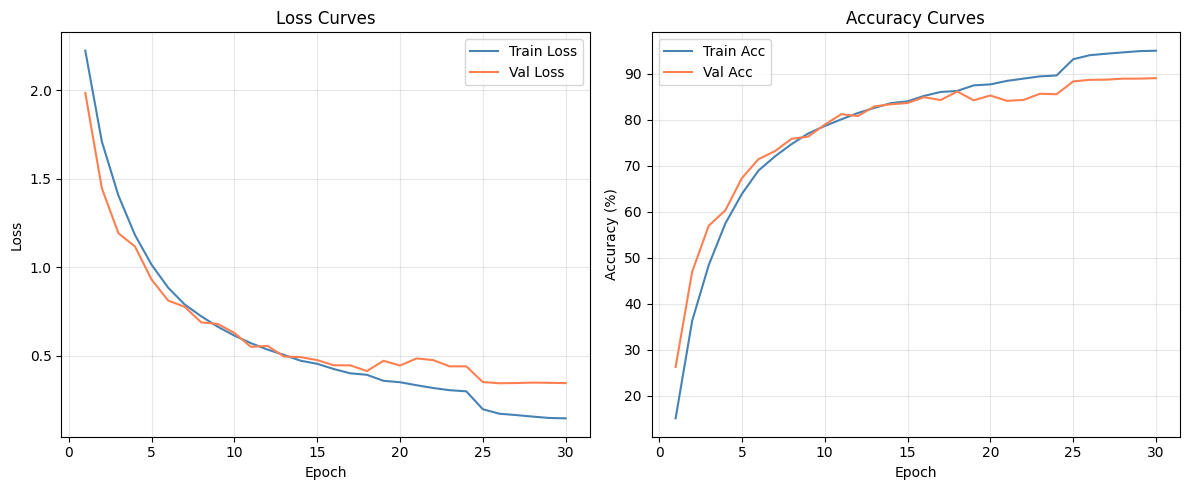


Final Val Accuracy (CIFAR-10): 89.09%


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time

# ─────────────────────────────────────────────
# 1. DEVICE SETUP
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# 2. ALEXNET ARCHITECTURE (Manual Implementation)
#    Matches paper exactly: Section 3.5
# ─────────────────────────────────────────────
class AlexNet(nn.Module):
    def __init__(self, num_classes=1000):
        super(AlexNet, self).__init__()

        # 5 Convolutional layers
        self.features = nn.Sequential(
            # Conv1: 96 kernels, 11×11, stride 4 → ReLU → LRN → MaxPool
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),

            # Conv2: 256 kernels, 5×5 → ReLU → LRN → MaxPool
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),

            # Conv3: 384 kernels, 3×3 → ReLU  (no pool)
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4: 384 kernels, 3×3 → ReLU  (no pool)
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5: 256 kernels, 3×3 → ReLU → MaxPool
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),
        )

        # 3 Fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),           # Dropout as described in Section 4.2
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes), # 1000-way for ImageNet
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)   # Flatten before FC layers
        x = self.classifier(x)
        return x

# ─────────────────────────────────────────────
# 3. COUNT PARAMETERS (should be ~60 million)
# ─────────────────────────────────────────────
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = AlexNet(num_classes=1000)
params = count_parameters(model)
print(f"Total parameters: {params:,}")   # Expected: ~60,965,224
print(f"Paper reports:    60,000,000")


# ─────────────────────────────────────────────
# 4. DATASET HANDLING — Using CIFAR-10
#    (ImageNet requires ~150GB; CIFAR-10 is practical for students)
# ─────────────────────────────────────────────

# Paper preprocessing steps (Section 2):
# - Resize to 256×256
# - Random 224×224 crop
# - Horizontal flip (data augmentation)
# - RGB PCA color jitter (data augmentation)
# - Subtract mean pixel value

# For CIFAR-10, we adapt these steps to 32×32 images
train_transform = transforms.Compose([
    transforms.Resize(256),             # Upscale to match paper
    transforms.RandomCrop(224),         # Random 224×224 crop (Section 4.1)
    transforms.RandomHorizontalFlip(),  # Horizontal reflection (Section 4.1)
    transforms.ColorJitter(             # Approximate PCA color augmentation
        brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(               # Subtract mean (Section 2)
        mean=[0.4914, 0.4822, 0.4465],  # CIFAR-10 channel means
        std=[0.2023, 0.1994, 0.2010]
    )
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),         # Use center crop at test time
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

# Download and load CIFAR-10
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# Paper uses batch size 128 (Section 5)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader  = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

print(f"Training samples: {len(trainset)}")
print(f"Test samples:     {len(testset)}")
CLASSES = trainset.classes
print(f"Classes: {CLASSES}")


# ─────────────────────────────────────────────
# 5. MODEL FOR CIFAR-10 (10 classes)
# ─────────────────────────────────────────────
model_cifar = AlexNet(num_classes=10).to(device)


# ─────────────────────────────────────────────
# 6. TRAINING PIPELINE — Follows Section 5 exactly
# ─────────────────────────────────────────────

# SGD with momentum and weight decay (Section 5)
optimizer = optim.SGD(
    model_cifar.parameters(),
    lr=0.01,            # Initial LR from paper
    momentum=0.9,       # Momentum from paper
    weight_decay=0.0005 # Weight decay from paper
)

# LR scheduler: divide by 10 when val error stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=5)

criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

# ─────────────────────────────────────────────
# 7. TRAINING LOOP
# ─────────────────────────────────────────────
NUM_EPOCHS = 30  # Paper trains for 90 cycles; reduce for demo
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("\nStarting training...")
for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model_cifar, trainloader, optimizer, criterion)
    va_loss, va_acc = evaluate(model_cifar, testloader, criterion)
    scheduler.step(va_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    elapsed = time.time() - t0
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {tr_loss:.3f}  Train Acc: {tr_acc:.1f}%  "
          f"Val Loss: {va_loss:.3f}  Val Acc: {va_acc:.1f}%  "
          f"({elapsed:.1f}s)")

print("\nTraining complete!")


# ─────────────────────────────────────────────
# 8. PRETRAINED ALEXNET ON IMAGENET
#    This is how you match the paper's reported numbers
# ─────────────────────────────────────────────

# Load the official pretrained AlexNet (trained on ImageNet)
pretrained = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
pretrained.eval().to(device)

# Standard ImageNet preprocessing
imagenet_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Quick test with a single image (use any .jpg file)
from PIL import Image
import urllib.request

# Download a sample image for testing
# Original URL caused HTTP Error 403. Using an alternative.
url = "https://hips.hearstapps.com/hmg-prod/images/cute-cat-photos-1593441022.jpg?crop=0.670xw:1.00xh;0.167xw,0&resize=640:*"
urllib.request.urlretrieve(url, "test_cat.jpg")

img = Image.open("test_cat.jpg").convert("RGB")
img_tensor = imagenet_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = pretrained(img_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Load ImageNet class labels
import json, urllib.request
labels_url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
with urllib.request.urlopen(labels_url) as f:
    imagenet_labels = json.load(f)

top5_prob, top5_idx = torch.topk(probabilities, 5)
print("\nTop-5 Predictions (pretrained AlexNet on ImageNet):")
print("-" * 45)
for i in range(5):
    label = imagenet_labels[top5_idx[i].item()]
    prob  = top5_prob[i].item() * 100
    print(f"  {i+1}. {label:<30} {prob:.2f}%")


# ─────────────────────────────────────────────
# 9. PLOT TRAINING CURVES
# ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
ax1.plot(epochs, history["val_loss"],   label="Val Loss",   color="coral")
ax1.set_title("Loss Curves"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history["train_acc"], label="Train Acc", color="steelblue")
ax2.plot(epochs, history["val_acc"],   label="Val Acc",   color="coral")
ax2.set_title("Accuracy Curves"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print(f"\nFinal Val Accuracy (CIFAR-10): {history['val_acc'][-1]:.2f}%")